# Project Analysis: Netflix Content Popularity

**Course:** CMSE 202  
**Completed Project Notebook**

**Group Members:**  
- Jaehan Kim — kimjaeha@msu.edu  
- Akshita Mylavarapu — mylavar2@msu.edu  
- Taliah Blom — blomtali@msu.edu  
- Ahmed Chishti — chishti2@msu.edu  

## Main Research Question

Can Netflix content features such as release year, rating, duration, genre, country, and content type help explain or predict popularity?

## Popularity Definition

In this project, popularity will mainly be measured using available popularity-related variables from the datasets, especially TMDB popularity, IMDb votes, IMDb score, and TMDB score.

## Dataset Sources

1. `Netflix Dataset.csv`  
   Source: https://www.kaggle.com/datasets/rohitgrewal/netflix-data

2. `netflix_titles.csv`  
   Source: https://www.kaggle.com/datasets/shivamb/netflix-shows

3. `credits.csv` and `titles.csv`  
   Source: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies



---

# 1. Import packages

These packages are used for data organization, cleaning, and basic analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

These packages are used for plots and data visualization.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

These packages are used for modeling.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, SVC
from sklearn.linear_model import Perceptron
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

---

# 2. Load the datasets

In [4]:
# File names
rohit_file = "data/Netflix Dataset.csv"
shivamb_file = "data/netflix_titles.csv"
credits_file = "data/credits.csv"
titles_file = "data/titles.csv"

# If the notebook is run in a folder without a data folder, use titles.csv in the current folder.
if not os.path.exists(titles_file) and os.path.exists("titles.csv"):
    titles_file = "titles.csv"


## 2.1 Load `titles.csv` dataset

In [5]:
titles_raw = pd.read_csv(titles_file)

print("Titles dataset shape:", titles_raw.shape)

display(titles_raw.head())

Titles dataset shape: (5850, 15)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


## 2.2 Load `credits.csv` dataset

In [6]:
credits_raw = pd.read_csv(credits_file)

print("Credits dataset shape:", credits_raw.shape)

display(credits_raw.head())

Credits dataset shape: (77801, 5)


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


---

# 3. Check and understand the data

## 3.1 `titles.csv`

Before cleaning, checking the columns, data types, missing values, and basic summary statistics.

In [7]:
print("Column names:")
print(titles_raw.columns.tolist())

Column names:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [8]:
titles_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

In [9]:
missing_values = titles_raw.isna().sum().sort_values(ascending=False)
display(missing_values)
display(titles_raw.describe())

seasons                 3744
age_certification       2619
imdb_votes               498
imdb_score               482
imdb_id                  403
tmdb_score               311
tmdb_popularity           91
description               18
title                      1
id                         0
type                       0
runtime                    0
release_year               0
genres                     0
production_countries       0
dtype: int64

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


## 3.2 `credits.csv`

In [10]:
print("Column names:")
print(credits_raw.columns.tolist())

Column names:
['person_id', 'id', 'name', 'character', 'role']


In [11]:
credits_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB


In [12]:
missing_values = credits_raw.isna().sum().sort_values(ascending=False)
display(missing_values)
display(credits_raw.describe())

character    9772
person_id       0
id              0
name            0
role            0
dtype: int64

,person_id
count,7.780100e+04
mean,5.294888e+05
std,6.430167e+05
min,7.000000e+00
25%,4.530600e+04
50%,1.983580e+05
75%,8.880960e+05
max,2.462818e+06


---

# 4. Clean dataset

## 4.1 `titles.csv`

Columns needed from titles.csv:

- id
- title
- type
- release_year
- runtime
- genres
- production_countries
- imdb_score
- imdb_votes
- tmdb_popularity
- tmdb_score

In [13]:
# Select only the columns we need
selected_columns = [
    "id", 
    "title",
    "type",
    "release_year",
    "runtime",
    "genres",
    "production_countries",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]

titles_clean = titles_raw[selected_columns].copy()

display(titles_clean.head())


,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,51,['documentation'],['US'],NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,1976,114,"['drama', 'crime']",['US'],8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"['drama', 'action', 'thriller', 'european']",['US'],7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"['fantasy', 'action', 'comedy']",['GB'],8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"['war', 'action']","['GB', 'US']",7.7,72662.0,20.398,7.600


In [14]:
# Removing duplicate rows
titles_clean = titles_clean.drop_duplicates()

# Dropping "[", "]", and "'" characters
titles_clean["genres"] = (
    titles_clean["genres"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean["production_countries"] = (
    titles_clean["production_countries"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

display(titles_clean.head())

,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,51,documentation,US,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600


In [15]:
# Convert number columns to numeric
number_columns = [
    "release_year",
    "runtime",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]

for col in number_columns:
    titles_clean[col] = pd.to_numeric(titles_clean[col], errors="coerce")

# Removing rows that are missing important values
titles_clean = titles_clean.dropna(
    subset=[
        "title",
        "type",
        "release_year",
        "runtime",
        "tmdb_popularity",
        "imdb_score",
        "imdb_votes",
        "tmdb_score",
        "id"
    ]
)

In [16]:
# Checking the resulted dataset
print("Cleaned titles dataset shape:", titles_clean.shape)
print("Cleaned titles dataset columns:")
print(titles_clean.columns.tolist())

display(titles_clean.head())
display(titles_clean.describe())

Cleaned titles dataset shape: (5131, 11)
Cleaned titles dataset columns:
['id', 'title', 'type', 'release_year', 'runtime', 'genres', 'production_countries', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600
5,ts22164,Monty Python's Flying Circus,SHOW,1969,30,"comedy, european",GB,8.8,73424.0,17.617,8.306


,release_year,runtime,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5131.000000,5131.000000,5131.000000,5.131000e+03,5131.000000,5131.000000
mean,2016.288053,78.840577,6.516079,2.434477e+04,24.097710,6.825211
std,7.035558,38.615331,1.152650,9.754941e+04,85.280431,1.146735
min,1954.000000,0.000000,1.600000,5.000000e+00,0.600000,1.000000
25%,2016.000000,46.000000,5.800000,6.120000e+02,3.140500,6.100000
50%,2018.000000,86.000000,6.600000,2.474000e+03,7.479000,6.900000
75%,2020.000000,105.000000,7.300000,1.028300e+04,17.606500,7.500000
max,2022.000000,225.000000,9.500000,2.294231e+06,2274.044000,10.000000


In [17]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
titles_clean.to_csv("data/cleaned_titles.csv", index=False)

## 4.2 `credits.csv`

Columns needed from credits.csv:

- id
- person_id
- name
- role

In [18]:
# Select only the columns we need
selected_columns = [
    "id", 
    "person_id",
    "name",
    "role"
]

credits_clean = credits_raw[selected_columns].copy()

display(credits_clean.head())

,id,person_id,name,role
0,tm84618,3748,Robert De Niro,ACTOR
1,tm84618,14658,Jodie Foster,ACTOR
2,tm84618,7064,Albert Brooks,ACTOR
3,tm84618,3739,Harvey Keitel,ACTOR
4,tm84618,48933,Cybill Shepherd,ACTOR


In [19]:
# Removing duplicate rows
credits_clean = credits_clean.drop_duplicates()

In [20]:
# Removing rows that are missing important values
credits_clean = credits_clean.dropna(
    subset=[
        "id",
        "person_id",
        "role"
    ]
)

In [21]:
# Checking the resulted dataset
print("Cleaned credits dataset shape:", credits_clean.shape)
print("Cleaned credits dataset columns:")
print(credits_clean.columns.tolist())

display(credits_clean.head())

Cleaned credits dataset shape: (77713, 4)
Cleaned credits dataset columns:
['id', 'person_id', 'name', 'role']


,id,person_id,name,role
0,tm84618,3748,Robert De Niro,ACTOR
1,tm84618,14658,Jodie Foster,ACTOR
2,tm84618,7064,Albert Brooks,ACTOR
3,tm84618,3739,Harvey Keitel,ACTOR
4,tm84618,48933,Cybill Shepherd,ACTOR


In [22]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
credits_clean.to_csv("data/cleaned_credits.csv", index=False)


## 4.3 Add directors and actors into `cleaned_titles.csv`

In [23]:
# Make two new columns in cleaned_titles.csv
# One column for actors, one column for directors

# Aggregate actor person_id values per title
actor_agg = (
    credits_clean[credits_clean["role"] == "ACTOR"]
    .groupby("id")["person_id"]
    .apply(lambda x: list(set(x))) # unique person_id values
    .reset_index()
    .rename(columns={"person_id": "actor_ids"})
)

# Aggregate director person_id values per title
director_agg = (
    credits_clean[credits_clean["role"] == "DIRECTOR"]
    .groupby("id")["person_id"]
    .apply(lambda x: list(set(x))) # unique person_id values
    .reset_index()
    .rename(columns={"person_id": "director_ids"})
)

# Merge with the cleaned titles
titles_clean = titles_clean.merge(actor_agg, on="id", how="left")
titles_clean = titles_clean.merge(director_agg, on="id", how="left")

# Fill missing values (titles with no actors/directors) with empty lists
titles_clean["actor_ids"] = titles_clean["actor_ids"].apply(
    lambda x: x if isinstance(x, list) else []
)
titles_clean["director_ids"] = titles_clean["director_ids"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Create numeric columns
titles_clean["num_actors"] = titles_clean["actor_ids"].apply(len)
titles_clean["num_directors"] = titles_clean["director_ids"].apply(len)


# Make lists into strings
titles_clean["actor_ids"] = (
    titles_clean["actor_ids"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean["director_ids"] = (
    titles_clean["director_ids"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean.head()

,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,actor_ids,director_ids,num_actors,num_directors
0,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179,"32267, 29068, 466061, 17421, 43791, 43279, 435...",3308,36,1
1,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300,"197405, 100262, 53804, 24509, 24510, 84031, 84...",17727,22,1
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811,"8327, 1275018, 1549, 919694, 90024, 156072, 40...","11473, 11475",45,2
3,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600,"35200, 35201, 35202, 35203, 35204, 21244, 3520...",1063,54,1
4,ts22164,Monty Python's Flying Circus,SHOW,1969,30,"comedy, european",GB,8.8,73424.0,17.617,8.306,"11472, 11473, 11474, 11475, 11476",,5,0


In [24]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

## 4.4 Compute actor and director leave-one-out average IMDb and TMDB scores

In [25]:
credits_with_imdb = credits_clean.merge(
    titles_clean[["id", "imdb_score"]],
    on="id",
    how="left"
)

# per-person title IMDb score and number of titles
person_stats = (
    credits_with_imdb.groupby("person_id")
    .agg(total_imdb=("imdb_score", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_imdb.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_imdb"] - row["imdb_score"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_imdb'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_imdb'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average IMDb score.
global_avg_imdb = titles_clean['imdb_score'].mean()
titles_clean['avg_actor_imdb'] = titles_clean['avg_actor_imdb'].fillna(global_avg_imdb)
titles_clean['avg_director_imdb'] = titles_clean['avg_director_imdb'].fillna(global_avg_imdb)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

In [26]:
credits_with_tmdb = credits_clean.merge(
    titles_clean[["id", "tmdb_score"]],
    on="id",
    how="left"
)

# per-person title TMDB score and number of titles
person_stats = (
    credits_with_tmdb.groupby("person_id")
    .agg(total_tmdb=("tmdb_score", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_tmdb.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_tmdb"] - row["tmdb_score"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_tmdb'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_tmdb'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average TMDB score.
global_avg_tmdb = titles_clean['tmdb_score'].mean()
titles_clean['avg_actor_tmdb'] = titles_clean['avg_actor_tmdb'].fillna(global_avg_tmdb)
titles_clean['avg_director_tmdb'] = titles_clean['avg_director_tmdb'].fillna(global_avg_tmdb)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

In [27]:
credits_with_tmdb_pop = credits_clean.merge(
    titles_clean[["id", "tmdb_popularity"]],
    on="id",
    how="left"
)

# per-person title TMDB popularity and number of titles
person_stats = (
    credits_with_tmdb_pop.groupby("person_id")
    .agg(total_tmdb_pop=("tmdb_popularity", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_tmdb_pop.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_tmdb_pop"] - row["tmdb_popularity"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_tmdb_pop'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_tmdb_pop'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average TMDB popularity.
global_avg_tmdb_pop = titles_clean['tmdb_popularity'].mean()
titles_clean['avg_actor_tmdb_pop'] = titles_clean['avg_actor_tmdb_pop'].fillna(global_avg_tmdb_pop)
titles_clean['avg_director_tmdb_pop'] = titles_clean['avg_director_tmdb_pop'].fillna(global_avg_tmdb_pop)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

---

# 5. Understanding the data

In this section, we perform an initial exploratory data analysis (EDA) to better understand the structure of the cleaned dataset. The goal here is to identify patterns, relationships, and potential issues in the data before moving on to more advanced analysis or modeling. The following are examined: the distribution of target variables, correlations between numerical features, and how popularity varies across different categorical features.

## 5.1 Basic descriptive statistics

First, the summary statistics are computed for the four primary variables of interest: the four popularity metrics. This gives a sense of their central tendency, spread, and range. We also examine the distribution of content types (Movies vs TV Shows) in the dataset, as this is a key categorical feature.

In [25]:
titles_df = pd.read_csv("data/cleaned_titles_with_persons.csv")

popularity_cols = ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]
display(titles_df[popularity_cols].describe())

titles_df["type"].value_counts()


,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5131.000000,5.131000e+03,5131.000000,5131.000000
mean,6.516079,2.434477e+04,24.097710,6.825211
std,1.152650,9.754941e+04,85.280431,1.146735
min,1.600000,5.000000e+00,0.600000,1.000000
25%,5.800000,6.120000e+02,3.140500,6.100000
50%,6.600000,2.474000e+03,7.479000,6.900000
75%,7.300000,1.028300e+04,17.606500,7.500000
max,9.500000,2.294231e+06,2274.044000,10.000000


type
MOVIE    3271
SHOW     1860
Name: count, dtype: int64

This summary reveals that:
- IMDb Score and TMDB Score are centered around the 6.5-6.8 range, with a relatively narrow spread (standard deviation ~1.15)
- IMDb Votes and TMDB Popularity are highly right-skewed, meaning most titles have relatively few votes/low popularity, while a small number of titles are extremely popular and drive the mean upwards. The median values are much lower than the means, confirming this skew.
- The dataset contains more Movie entries (3271) than TV Show entries (1860).

## 5.2 Distribution plots of popularity metrics

Next, the distribution of each popularity metric is visualized using histograms with a Kernel Density Estimate (KDE) overlay. This helps us see the shape of the data more clearly, confirming the skew seen in the summary statistics.

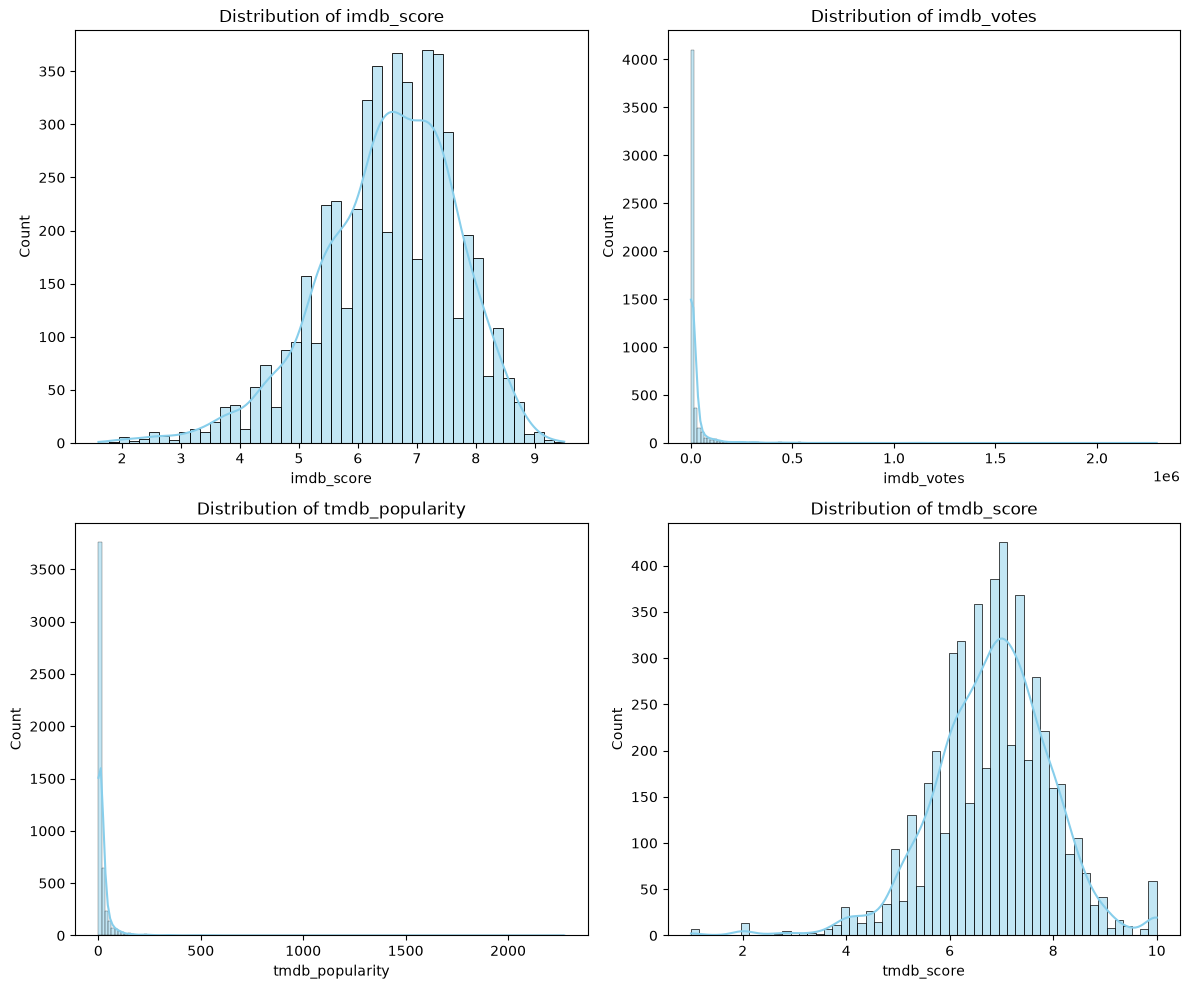

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for i, col in enumerate(popularity_cols):
    sns.histplot(titles_df[col], kde=True, ax=axes[i//2, i%2], color="skyblue")
    axes[i//2, i%2].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

The histograms confirm that IMDb Score and TMDB Score are roughly normally distributed. In contrast, IMDb Votes and TMDB Popularity are heavily skewed to the right, with long tails representing a small number of highly popular or well-known titles. This skewness is important to consider when choosing a target variable for modeling.

## 5.3 Correlation matrix of numeric features

To understand the linear relationships between all numeric variables in the dataset, we create a correlation matrix.

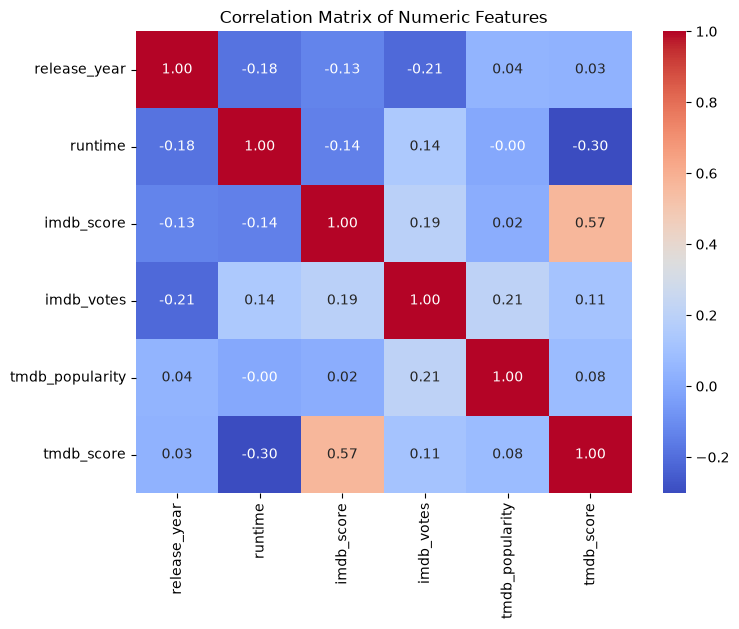

In [27]:
numeric_cols = ["release_year", "runtime", "imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]
corr = titles_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

As expected, IMDb Score and TMDB Score are strongly correlated. This suggests they are capturing a similar underlying concept of user/audience rating. IMDb Votes and TMDB Popularity are also moderately correlated, indicating that titles with more votes tend to have higher popularity scores. Release year and runtime show very weak correlations with all popularity metrics, suggesting they may not be strong predictors on their own.

## 5.4 Explore relationships with categorical features

Here, we examine how the popularity metrics differ across the two main content types: TV Shows and Movies.

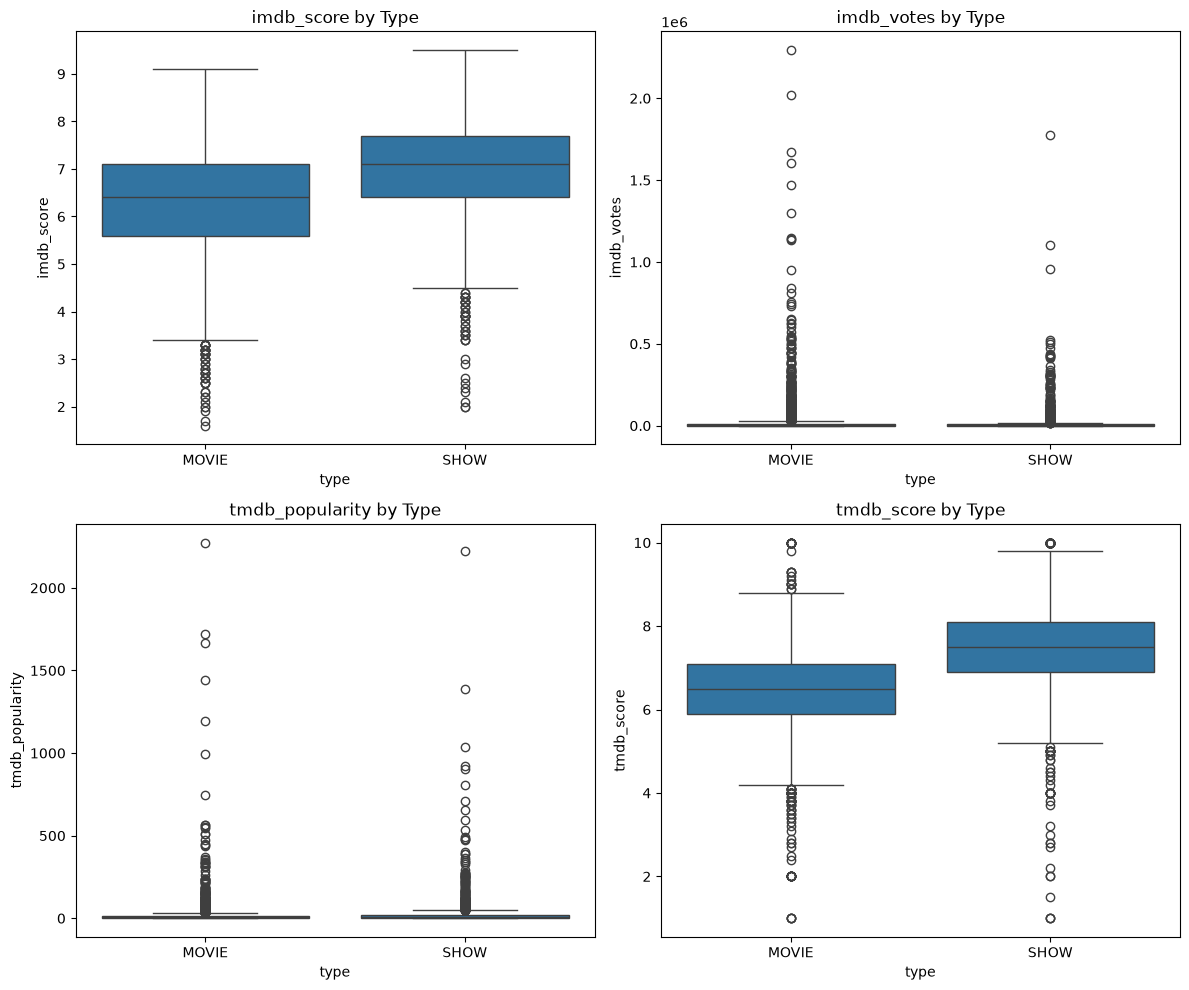

,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
type,,,,
MOVIE,6.251085,28062.296851,21.506184,6.457378
SHOW,6.982097,17807.109140,28.655174,7.472083


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for i, col in enumerate(popularity_cols):
    sns.boxplot(x="type", y=col, data=titles_df, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f"{col} by Type")
plt.tight_layout()
plt.show()

titles_df.groupby("type")[popularity_cols].mean()

TV Shows generally have higher average IMDb Score and TMDB Score compared to Movies. However, Movies have a significantly higher average of IMDb Votes. This suggests that while TV Shows may be rated slightly higher, Movies tend to attract more individual voter engagement. This could be due to the different nature of consuming a film versus a series.

## 5.5 Scatter plots for continuous features vs popularity

Finally, we visualize the relationship between release year and our popularity metrics. By coloring the points by type, we can also see if the trend differs for Movies and TV Shows.

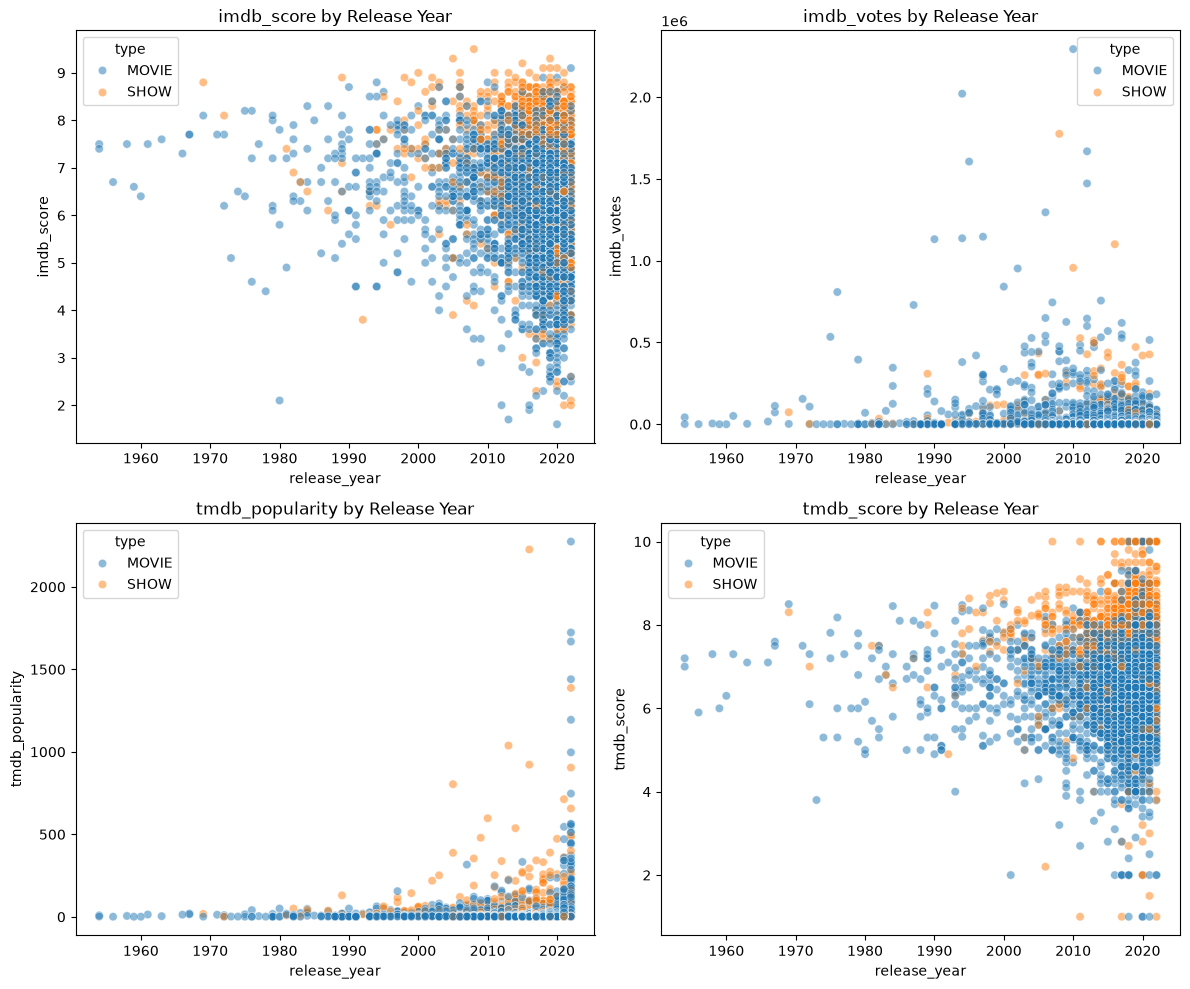

In [29]:
# Release year vs popularities
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for i, col in enumerate(popularity_cols):
    sns.scatterplot(x="release_year", y=col, hue="type", data=titles_df, ax=axes[i//2, i%2], alpha=0.5)
    axes[i//2, i%2].set_title(f"{col} by Release Year")
plt.tight_layout()
plt.show()

The scatter plots reveal no strong linear trend between release year and any of the popularity metrics. The relationship appears weak and noisy. The distribution of data points is denser for recent years, which is expected as Netflix's library is heavily skewed towards newer content. This visual analysis reinforces the low correlation values seen earlier for release year, suggesting it may not be a simple linear predictor of popularity on its own.

Finally, we visualize the relationship between runtime and our popularity metrics. By coloring the points by type, we can also see if the trend differs for Movies and TV Shows.

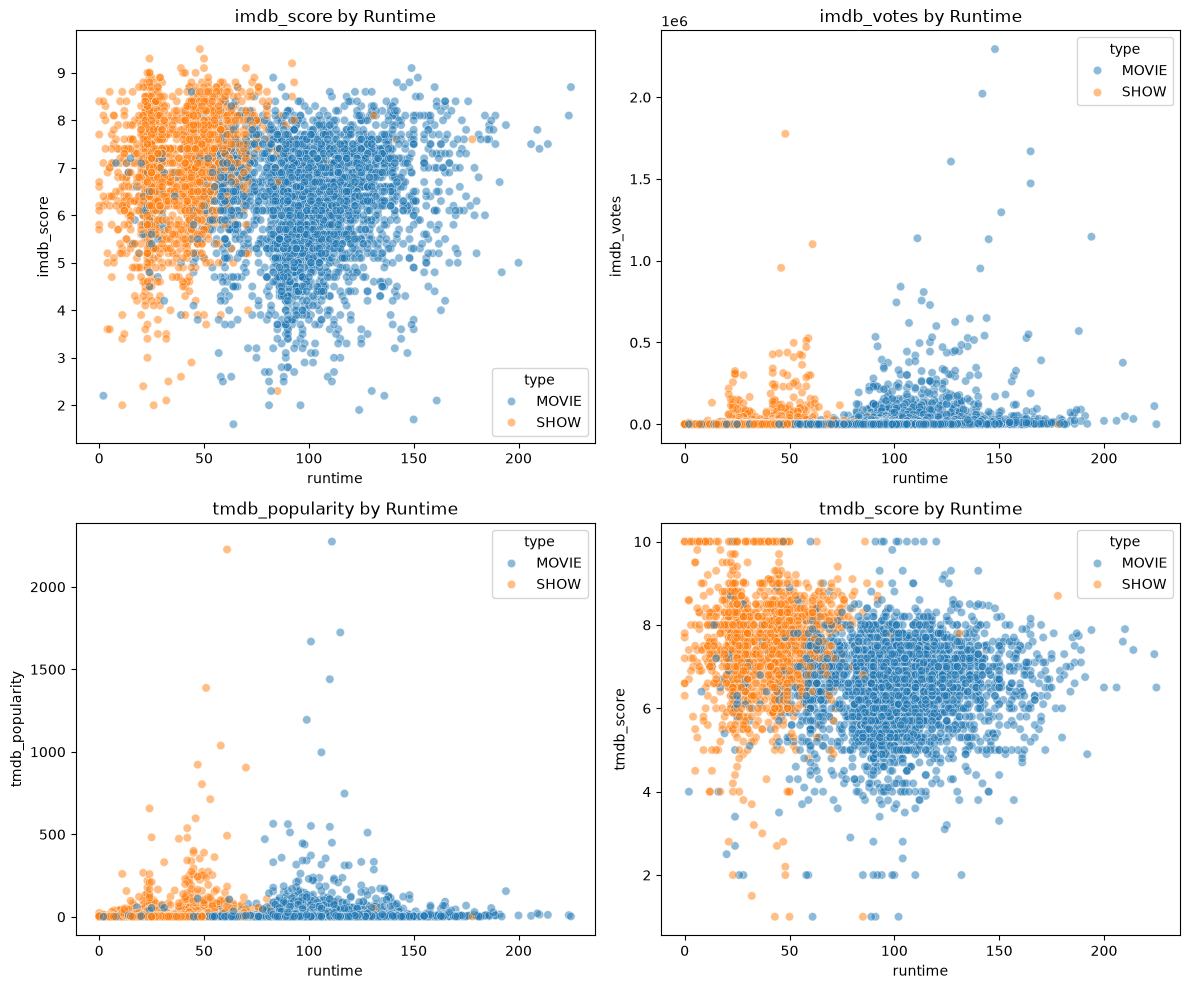

In [30]:
# Runtime vs popularities
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for i, col in enumerate(popularity_cols):
    sns.scatterplot(x="runtime", y=col, hue="type", data=titles_df, ax=axes[i//2, i%2], alpha=0.5)
    axes[i//2, i%2].set_title(f"{col} by Runtime")
plt.tight_layout()
plt.show()

The scatter plots reveal no strong linear trend between runtime and any of the popularity metrics. The relationship appears weak and noisy. The distribution of type around runtime is well-clustered, which is expected as TV Show episodes typically have a much lower runtime than a Movie. Overall, this visual analysis reinforces the low correlation values seen earlier for runtime, suggesting it may not be a simple linear predictor of popularity on its own.

# 6. Modeling

In this section, we build predictive models to assess how well the content features (release year, runtime, type, genre, and production country) can explain or predict popularity. We treat this both as a regression problem (predicting a continuous popularity metric) and a classification problem (predicting whether a title is in the top quartile of popularity). This allows us to compare different modeling strategies and gain insight into the most influential features.

## 6.1 Feature engineering

Before modeling, we transform the categorical features:
- `type`: Converted to a binary indicator `is_movie` (1 for movies, 0 for TV shows)
- `genres`: One-hot encoded into binary columns (e.g., `genre_drama`, `genre_comedy`)
- `production_countries`: One-hot encoded, but to keep dimensionality manageable, we only retain the top 50 countries

All numeric features (`release_year`, `runtime`) are standardized to work well with models like SVR and Perceptron.

In [31]:
# For data safety, reload the data
titles_df = pd.read_csv("data/cleaned_titles_with_persons.csv")

# Make type a binary feature
titles_df["is_movie"] = (titles_df["type"] == "MOVIE").astype(int)

# Split genres and create dummies
genre_dummies = titles_df["genres"].str.get_dummies(sep=", ")
genre_dummies = genre_dummies.add_prefix("genre_")
titles_df = pd.concat([titles_df, genre_dummies], axis=1)

# Split production countries and create dummies
country_dummies = titles_df["production_countries"].str.get_dummies(sep=", ")
top_50_countries = country_dummies.sum().sort_values(ascending=False).head(50).index.tolist()
country_dummies_top50 = country_dummies[top_50_countries]
country_dummies_top50 = country_dummies_top50.add_prefix("country_")
titles_df = pd.concat([titles_df, country_dummies_top50], axis=1)

In [32]:
# Select features to use in modeling
feature_cols = ["release_year", "runtime", "is_movie", "num_actors", "num_directors"] + \
    [col for col in titles_df.columns if col.startswith("genre_")] + \
    [col for col in titles_df.columns if col.startswith("country_")]

## 6.2 Modeling pipeline

We define a single function `run_modeling` that trains and evaluates several models for a given popularity target. The function:
- Splits data into training and test sets
- Standardizes all numeric features for SVR and Perceptron
- Runs Linear Regression and SVR on the original target and on a log-transformed version to handle skewness
- Builds a binary classification task to predict whether a title is in the top quartile of the target metric
- Applies SVR and a Perceptron classifier

We then evaluate all models using:
- Regression: Root mean squared error (RMSE), mean absolute error (MAE), and R2 score
- Classification: Accuracy, precision, and recall

The results are collected into a DataFrame for easy comparison.

In [33]:
def run_modeling(target_col, df, threshold_quantile=0.75, random_state=42, test_size=0.2, C=1.0, epsilon=0.1, perc_max_iter=10_000):
    """
    Run regression and classification models for a given popularity metric.

    Inputs:
        target_col (str) : Name of the target column in df (e.g., 'tmdb_popularity')
        df (pd.DataFrame) : Cleaned dataframe with all feature dummies already added
        threshold_quantile (float, default=0.75) : Quantile used to define the binary 'popular' class
        random_state (int, default=42) : Seed for reproducible splits
        test_size (float, default=0.2) : Split size for data testing
        C (float, default=1.0) : C value for SVR and SVC
        epsilon (float, default=0.1) : epsilon value for SVR
        perc_max_iter (int, default=10000) : Maximum iterations for the Perceptron

    Returns:
        dict : Dictionary containing all performance metrics
    """
    # Features and target
    x = df[feature_cols].copy()
    y = df[target_col].copy()

    # Log-transform for skewed targets
    y_log = np.log1p(y) # log(1+y) to avoid log(0)

    # Split data for regression
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=random_state
    )
    x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(
        x, y_log, test_size=test_size, random_state=random_state
    )

    # Scale features for models that rely on distance
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    scaler_log = StandardScaler()
    x_train_scaled_log = scaler_log.fit_transform(x_train_log)
    x_test_scaled_log = scaler_log.transform(x_test_log)

    # Linear regression
    lr = LinearRegression()
    lr.fit(x_train_scaled, y_train)
    y_pred_lr = lr.predict(x_test_scaled)

    lr_log = LinearRegression()
    lr_log.fit(x_train_scaled_log, y_train_log)
    y_pred_lr_log = lr_log.predict(x_test_scaled_log)
    y_pred_lr_orig = np.expm1(y_pred_lr_log) # back to original scale

    # SVR
    svr = SVR(kernel="rbf", C=C, epsilon=epsilon)
    svr.fit(x_train_scaled, y_train)
    y_pred_svr = svr.predict(x_test_scaled)

    svr_log = SVR(kernel="rbf", C=C, epsilon=epsilon)
    svr_log.fit(x_train_scaled_log, y_train_log)
    y_pred_svr_log = svr_log.predict(x_test_scaled_log)
    y_pred_svr_orig = np.expm1(y_pred_svr_log) # back to original scale

    # Classification setup (binary target)
    threshold = df[target_col].quantile(threshold_quantile)
    y_class = (df[target_col] >= threshold).astype(int)

    x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(
        x, y_class, test_size=test_size, random_state=random_state
    )
    scaler_cls = StandardScaler()
    x_train_cls_scaled = scaler_cls.fit_transform(x_train_cls)
    x_test_cls_scaled = scaler_cls.transform(x_test_cls)

    # SVC
    svc = SVC(kernel="rbf", C=C, random_state=random_state)
    svc.fit(x_train_cls_scaled, y_train_cls)
    y_pred_svc = svc.predict(x_test_cls_scaled)

    # Perceptron
    perc = Perceptron(max_iter=perc_max_iter, random_state=random_state)
    perc.fit(x_train_cls_scaled, y_train_cls)
    y_pred_perc = perc.predict(x_test_cls_scaled)

    # Collect metrics
    results = {
        "target": target_col,
        # Regression (original)
        "LR_RMSE_orig": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        "LR_MAE_orig": mean_absolute_error(y_test, y_pred_lr),
        "LR_R2_orig": r2_score(y_test, y_pred_lr),
        # Regression (log)
        "LR_RMSE_log": np.sqrt(mean_squared_error(y_test, y_pred_lr_orig)),
        "LR_MAE_log": mean_absolute_error(y_test, y_pred_lr_orig),
        "LR_R2_log": r2_score(y_test, y_pred_lr_orig),
        # SVR (original)
        "SVR_RMSE_orig": np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        "SVR_MAE_orig": mean_absolute_error(y_test, y_pred_svr),
        "SVR_R2_orig": r2_score(y_test, y_pred_svr),
        # SVR (log)
        "SVR_RMSE_log": np.sqrt(mean_squared_error(y_test, y_pred_svr_orig)),
        "SVR_MAE_log": mean_absolute_error(y_test, y_pred_svr_orig),
        "SVR_R2_log": r2_score(y_test, y_pred_svr_orig),
        # Classification
        "SVC_accuracy": accuracy_score(y_test_cls, y_pred_svc),
        "SVC_precision": precision_score(y_test_cls, y_pred_svc),
        "SVC_recall": recall_score(y_test_cls, y_pred_svc),
        "Perceptron_accuracy": accuracy_score(y_test_cls, y_pred_perc),
        "Perceptron_precision": precision_score(y_test_cls, y_pred_perc),
        "Perceptron_recall": recall_score(y_test_cls, y_pred_perc),
        # Store confusion matrices
        "SVC_confusion": confusion_matrix(y_test_cls, y_pred_svc).tolist(),
        "Perceptron_confusion": confusion_matrix(y_test_cls, y_pred_perc).tolist()
    }
    return results

## 6.3 Results and interpretation

In [34]:
targets = ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]

all_results = []
for tgt in targets:
    print(f"=== Modeling for target: {tgt} ===")
    res = run_modeling(tgt, titles_df)
    all_results.append(res)
    # Print a concise summary for each target
    print(f"LR (orig)  R²: {res['LR_R2_orig']:.4f}  |  LR (log)  R²: {res['LR_R2_log']:.4f}")
    print(f"SVR (orig) R²: {res['SVR_R2_orig']:.4f}  |  SVR (log) R²: {res['SVR_R2_log']:.4f}")
    print(f"SVC accuracy: {res['SVC_accuracy']:.4f}  |  Perceptron accuracy: {res['Perceptron_accuracy']:.4f}")
    print()

# Convert results to a DataFrame for easy comparison
results_df = pd.DataFrame(all_results)
display(results_df)

=== Modeling for target: imdb_score ===
LR (orig)  R²: 0.2501  |  LR (log)  R²: 0.2367
SVR (orig) R²: 0.2886  |  SVR (log) R²: 0.2828
SVC accuracy: 0.7381  |  Perceptron accuracy: 0.6378

=== Modeling for target: imdb_votes ===
LR (orig)  R²: 0.2460  |  LR (log)  R²: 0.2518
SVR (orig) R²: -0.0465  |  SVR (log) R²: 0.2008
SVC accuracy: 0.8315  |  Perceptron accuracy: 0.7575

=== Modeling for target: tmdb_popularity ===
LR (orig)  R²: 0.0315  |  LR (log)  R²: 0.0183
SVR (orig) R²: -0.0129  |  SVR (log) R²: 0.0131
SVC accuracy: 0.7965  |  Perceptron accuracy: 0.7527

=== Modeling for target: tmdb_score ===
LR (orig)  R²: 0.2631  |  LR (log)  R²: 0.2508
SVR (orig) R²: 0.2826  |  SVR (log) R²: 0.2373
SVC accuracy: 0.7624  |  Perceptron accuracy: 0.6806



,target,LR_RMSE_orig,LR_MAE_orig,LR_R2_orig,LR_RMSE_log,LR_MAE_log,LR_R2_log,SVR_RMSE_orig,SVR_MAE_orig,SVR_R2_orig,...,SVR_MAE_log,SVR_R2_log,SVC_accuracy,SVC_precision,SVC_recall,Perceptron_accuracy,Perceptron_precision,Perceptron_recall,SVC_confusion,Perceptron_confusion
0,imdb_score,0.992098,0.769454,0.250146,1.000941,0.784591,0.236720,0.966345,0.731350,0.288571,...,0.756817,0.282753,0.738072,0.660194,0.225166,0.637780,0.400000,0.463576,"[[690, 35], [234, 68]]","[[515, 210], [162, 140]]"
1,imdb_votes,99496.114458,36504.238678,0.245976,99108.162352,22317.854255,0.251845,117215.907943,26440.462613,-0.046516,...,21854.179844,0.200825,0.831548,0.783951,0.479245,0.757546,0.525974,0.611321,"[[727, 35], [138, 127]]","[[616, 146], [103, 162]]"
2,tmdb_popularity,73.501510,27.046262,0.031528,74.002954,19.022151,0.018269,75.166802,19.067582,-0.012853,...,18.459554,0.013084,0.796495,0.713235,0.363296,0.752678,0.524164,0.528090,"[[721, 39], [170, 97]]","[[632, 128], [126, 141]]"
3,tmdb_score,0.956341,0.715598,0.263141,0.964313,0.724580,0.250806,0.943642,0.698830,0.282580,...,0.730742,0.237342,0.762415,0.618785,0.390244,0.680623,0.415638,0.351916,"[[671, 69], [175, 112]]","[[598, 142], [186, 101]]"


The table above shows the performance of each model for the four popularity metrics. Key observations:
- $R^2$ scores are generally low, indicating that the chosen features explain only a small portion of the variance in popularity. This suggests that popularity is influenced by many factors not captured in our dataset (e.g., marketing, cast, release timing), which is expected.
- Log-transforming skewed targets (`imdb_votes` and `tmdb_popularity`) sometimes improves performance slightly (especially for SVR), but the overall predictive power remains limited.
- Classification accuracy is higher (~70-80%) because the top-quartile threshold creates a somewhat balanced binary problem. However, recall and precision vary. For `imdb_score`, the classifier has a poor recall for the positive class, meaning it misses many truly popular titles. This indicates that the features are better at identifying non-popular titles than popular ones.

Overall, the models suggest that content features alone are insufficient to accurately predict popularity. Continued work in this project will incorporate additional data like cast, director, number of seasons, and other external factors to improve predictive performance.

## 6.4 Model performance visualizations

The following plots compare model performance across the four popularity metrics.

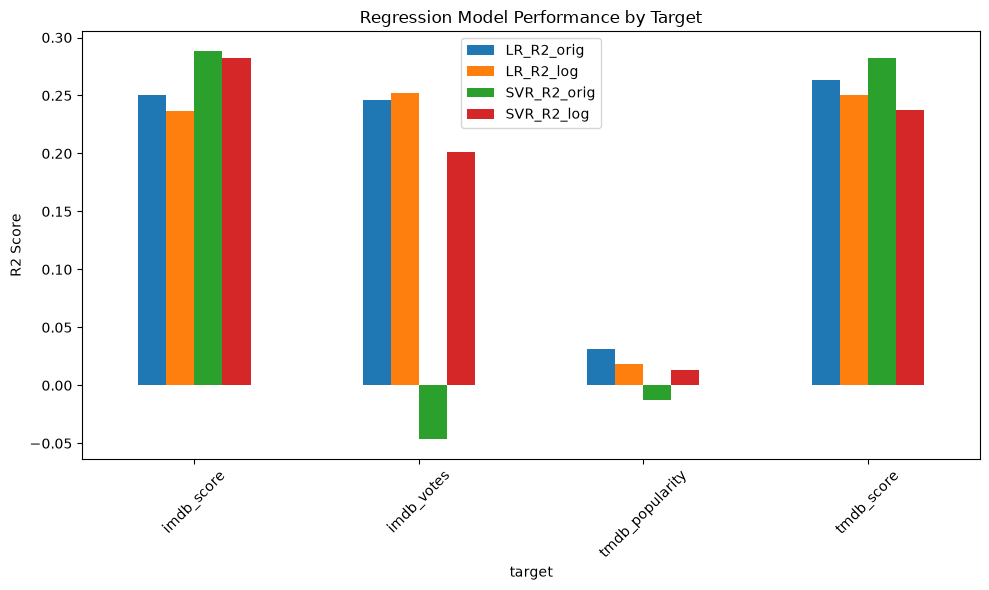

In [35]:
# Compare regression R2 scores
r2_cols = ["LR_R2_orig", "LR_R2_log", "SVR_R2_orig", "SVR_R2_log"]

results_df.set_index("target")[r2_cols].plot(kind="bar", figsize=(10, 6))

plt.ylabel("R2 Score")
plt.title("Regression Model Performance by Target")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

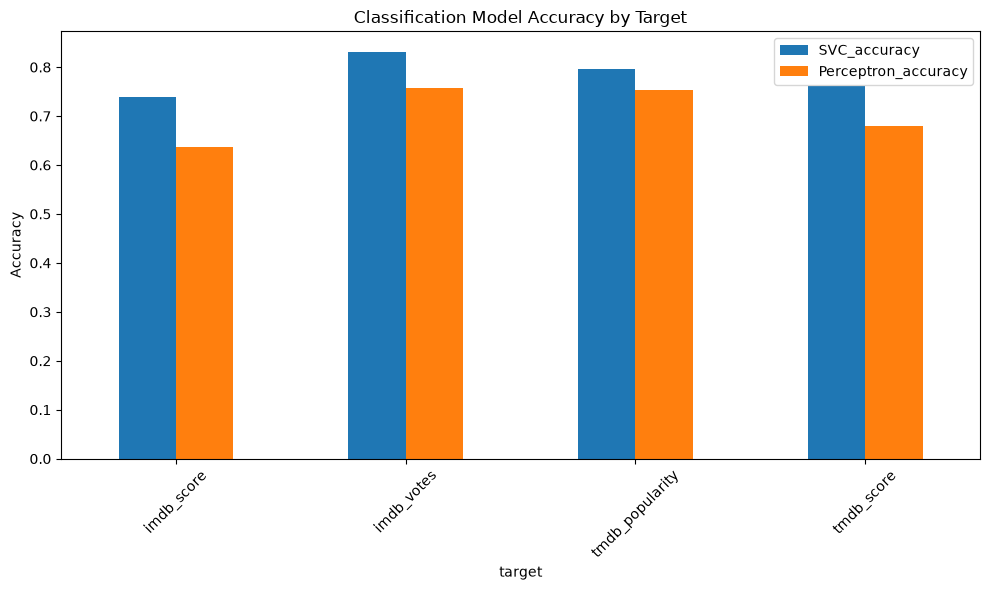

In [36]:
# Compare classification accuracy
accuracy_cols = ["SVC_accuracy", "Perceptron_accuracy"]

results_df.set_index("target")[accuracy_cols].plot(kind="bar", figsize=(10, 6))

plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy by Target")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The regression models generally have low R2 scores, meaning the content features alone do not explain popularity very well. The classification models perform better, especially SVC, but they still do not perfectly identify highly popular titles.

## 6.5 Confusion matrix for main target

Since TMDB popularity is the main popularity variable, we examine the SVC confusion matrix for this target.

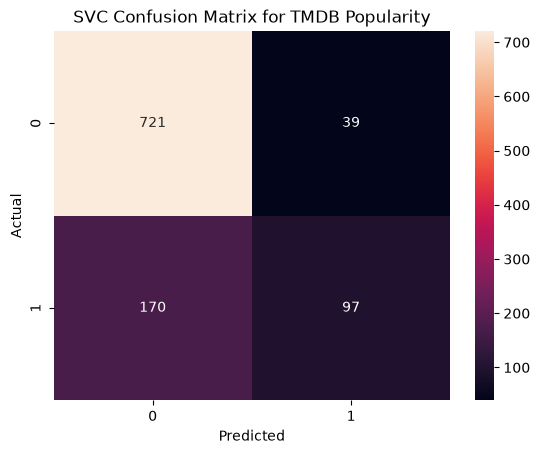

In [37]:
# Confusion matrix for SVC using tmdb_popularity
main_target = "tmdb_popularity"

tmdb_row = results_df[results_df["target"] == main_target].iloc[0]
cm = np.array(tmdb_row["SVC_confusion"])

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix for TMDB Popularity")
plt.show()

The confusion matrix shows how many titles were correctly and incorrectly classified as popular or not popular. This helps us see that the model can identify many non-popular titles, but it may still miss some truly popular titles.

## 6.6 Feature importance

To understand which features are most related to popularity, we examine the largest Linear Regression coefficients for the log-transformed TMDB popularity target.

In [38]:
# Feature importance using Linear Regression coefficients
main_target = "tmdb_popularity"

x = titles_df[feature_cols].copy()
y = np.log1p(titles_df[main_target])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_features = coef_df.sort_values("abs_coefficient", ascending=False).head(15)

display(top_features)


,feature,coefficient,abs_coefficient
25,country_IN,-0.311825,0.311825
1,runtime,0.278627,0.278627
2,is_movie,-0.235535,0.235535
3,num_actors,0.170930,0.170930
24,country_US,0.162527,0.162527
37,country_PH,-0.142535,0.142535
15,genre_horror,0.139785,0.139785
5,genre_action,0.135861,0.135861
18,genre_romance,0.131230,0.131230
10,genre_drama,0.117683,0.117683


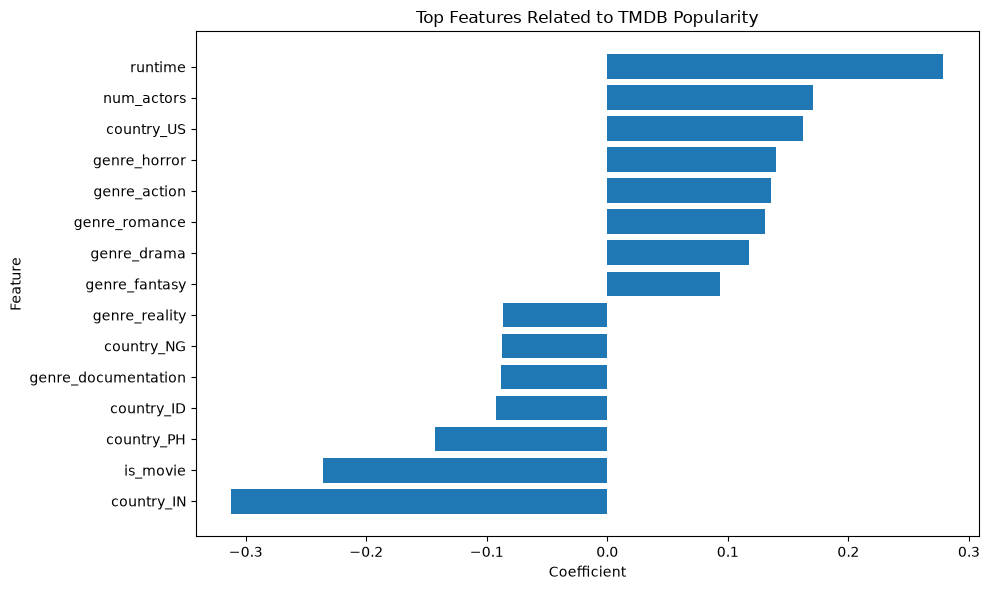

In [39]:
# Plot top feature coefficients
top_features_sorted = top_features.sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features_sorted["feature"], top_features_sorted["coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Related to TMDB Popularity")
plt.tight_layout()
plt.show()

The feature importance results suggest which content features are most associated with TMDB popularity in the linear model. However, these coefficients should be interpreted carefully because the overall regression performance is still weak.

# 7. Answering the research questions

**1. How do movies and TV shows differ?**  
The dataset contains more movies than TV shows. TV shows tend to have slightly higher IMDb and TMDB scores, while movies tend to have more IMDb votes.

**2. Which features seem most related to popularity?**  
IMDb votes and TMDB popularity are related, and IMDb score and TMDB score are strongly related. Release year and runtime do not show strong simple relationships with popularity. Some genre and country features appear in the feature importance results, but the overall predictive power is limited.

**3. Can we build a simple model to predict high-popularity vs low-popularity content?**  
Yes, we built classification models using SVC and Perceptron. SVC performed better than the Perceptron for most targets, but the model is still not perfect.

# 8. Final conclusion

Overall, our results show that Netflix content features such as release year, runtime, type, genre, and production country can explain some patterns in popularity, but they are not strong enough to accurately predict popularity by themselves.

The regression models had low R2 scores, especially for highly skewed metrics such as IMDb votes and TMDB popularity. This means the selected features explain only a small part of the variation in popularity. The classification models performed better, with SVC reaching around 70-80% accuracy for several targets, but accuracy alone does not mean the model is perfect.

The main conclusion is that content metadata alone is not enough to fully predict Netflix popularity. Popularity is probably also affected by other factors such as actors, directors, marketing, release timing, and Netflix promotion.